In [ ]:
import glob
label_ids = set()
for lf in glob.glob(f"{RUOD_TRAIN_LBL}/*.txt"):
    with open(lf) as f:
        for line in f:
            label_ids.add(int(line.split()[0]))
print(sorted(label_ids))  # Should be 0–27

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.5 MB/s eta 0:00:0000:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device : cuda
PyTorch: 2.10.0+cu128
Total classes: 28
[YAML] Saved → /kaggle/working/ruod_baseline.yaml
       Classes : 28
       Train   : /kaggle/input/datasets/sainikitha1317/ruod-dataset/train/images
       Val     : /kaggle/input/datasets/sainikitha1317/ruod-dataset/valid/images

[Dataset] Train: 2087 | Val: 602 | Test: 292

  BASELINE TRAINING: YOLOv8s | Raw RUOD | 30 Epochs
Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, c

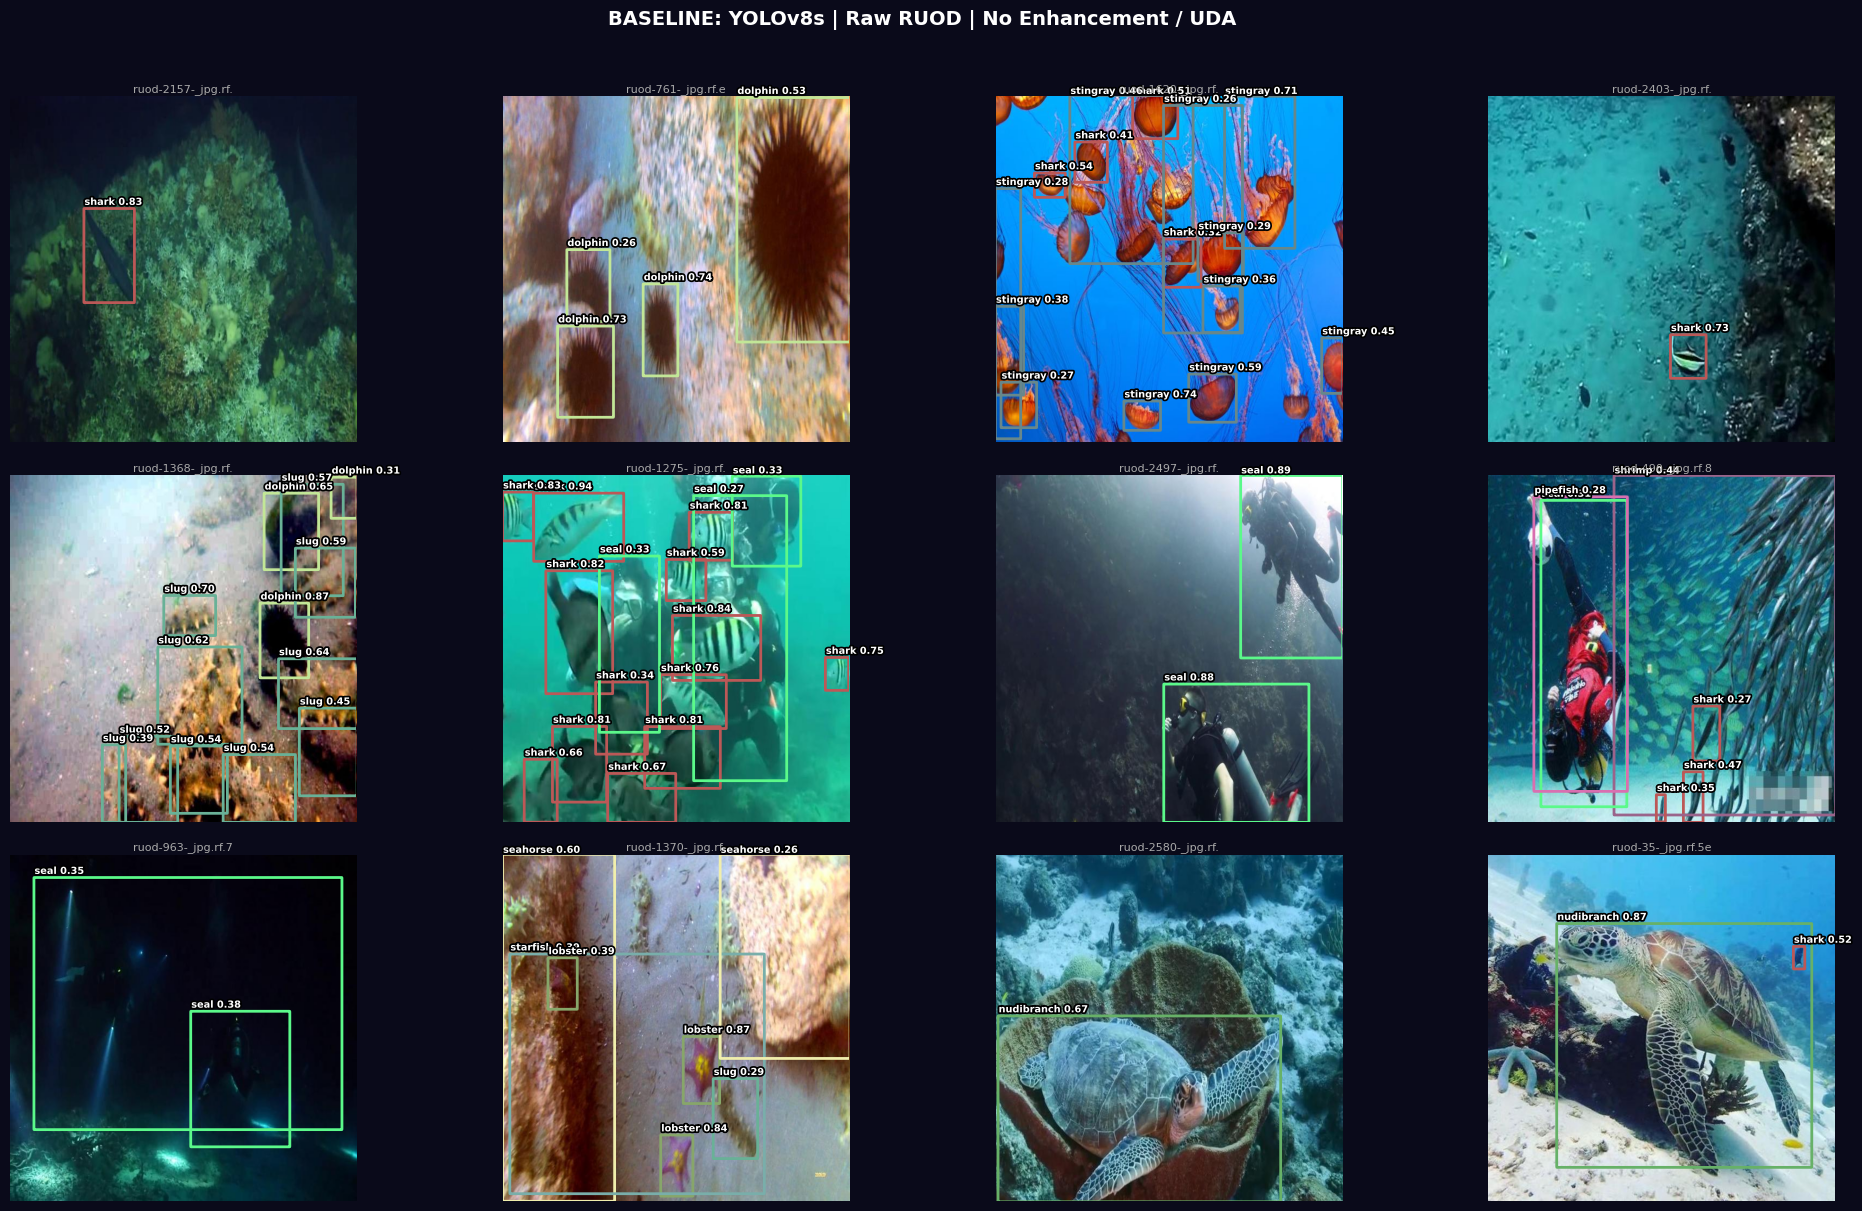


[Visualization] Saved → /kaggle/working/baseline_detections.png

  FINAL BASELINE SUMMARY
  Model   : YOLOv8s (yolov8s.pt)
  Dataset : RUOD (Raw, No Enhancement)
  Epochs  : 30  |  Batch: 8  |  ImgSz: 640
  mAP@50      : 0.4036
  mAP@50-95   : 0.2756
  Precision   : 0.4934
  Recall      : 0.4505
  F1 Score    : 0.4710
  Top Detected Classes (Test Sample):
    shark                23 detections
    stingray             11 detections
    slug                 11 detections
    seal                  8 detections
    dolphin               7 detections
    lobster               3 detections
    seahorse              2 detections
    nudibranch            2 detections
    shrimp                1 detections
    pipefish              1 detections
  ✅ Baseline complete. Compare against:
     Enhancement (LightUNet+CBAM) + UDA + RT-DETR


In [1]:
# ============================================================
# BASELINE: YOLOv8s on Raw RUOD Dataset
# Pure Detection – No Enhancement / UDA / CBAM
# ============================================================

# ============================================================
# CELL 1: Install Dependencies
# ============================================================
!pip install ultralytics -q

# ============================================================
# CELL 2: Imports and Configuration
# ============================================================
import os
import glob
import yaml
import shutil
import random
from pathlib import Path
from collections import Counter

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patheffects as pe
from PIL import Image
from ultralytics import YOLO

# ─── Device ─────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

# ─── Dataset Paths ──────────────────────────────────────────
RUOD_TRAIN_IMG = "/kaggle/input/datasets/sainikitha1317/ruod-dataset/train/images"
RUOD_TRAIN_LBL = "/kaggle/input/datasets/sainikitha1317/ruod-dataset/train/labels"
RUOD_VAL_IMG   = "/kaggle/input/datasets/sainikitha1317/ruod-dataset/valid/images"
RUOD_VAL_LBL   = "/kaggle/input/datasets/sainikitha1317/ruod-dataset/valid/labels"
RUOD_TEST_IMG  = "/kaggle/input/datasets/sainikitha1317/ruod-dataset/test/images"

# ─── Output Paths ───────────────────────────────────────────
WORKING        = "/kaggle/working"
YAML_PATH      = f"{WORKING}/ruod_baseline.yaml"
TRAIN_OUT_DIR  = f"{WORKING}/yolov8s_baseline"
VIZ_OUT        = f"{WORKING}/baseline_detections.png"

# ─── Training Config ────────────────────────────────────────
MODEL_VARIANT  = "yolov8s.pt"
EPOCHS         = 30
BATCH          = 8
IMG_SIZE       = 640
WORKERS        = 2
CONF_THRESH    = 0.25
IOU_THRESH     = 0.45

# ─── RUOD 28 Classes ────────────────────────────────────────
# NOTE: Verify order matches your dataset's label indices (0-27)
RUOD_CLASSES = [
    "fish",        # 0
    "jellyfish",   # 1
    "penguin",     # 2
    "puffin",      # 3
    "shark",       # 4
    "stingray",    # 5
    "turtle",      # 6
    "coral",       # 7
    "crab",        # 8
    "dolphin",     # 9
    "eel",         # 10
    "frogfish",    # 11
    "lobster",     # 12
    "nudibranch",  # 13
    "octopus",     # 14
    "otter",       # 15
    "pipefish",    # 16
    "ray",         # 17
    "seahorse",    # 18
    "seabird",     # 19
    "seal",        # 20
    "shrimp",      # 21
    "slug",        # 22
    "squid",       # 23
    "starfish",    # 24
    "whale",       # 25
    "cuttlefish",  # 26
    "clam",        # 27
]
NUM_CLASSES = len(RUOD_CLASSES)
print(f"Total classes: {NUM_CLASSES}")

# ─── Color Palette (one per class) ──────────────────────────
random.seed(42)
CLASS_COLORS = {
    name: tuple(random.randint(80, 255) for _ in range(3))
    for name in RUOD_CLASSES
}

# ============================================================
# CELL 3: YAML Creation
# ============================================================
def create_yaml():
    """Create RUOD dataset YAML for Ultralytics YOLO."""
    cfg = {
        "path" : WORKING,
        "train": RUOD_TRAIN_IMG,
        "val"  : RUOD_VAL_IMG,
        "nc"   : NUM_CLASSES,
        "names": RUOD_CLASSES,
    }
    with open(YAML_PATH, "w") as f:
        yaml.dump(cfg, f, default_flow_style=False, sort_keys=False)
    print(f"[YAML] Saved → {YAML_PATH}")
    print(f"       Classes : {NUM_CLASSES}")
    print(f"       Train   : {RUOD_TRAIN_IMG}")
    print(f"       Val     : {RUOD_VAL_IMG}")

create_yaml()

# Quick sanity check
train_imgs = glob.glob(f"{RUOD_TRAIN_IMG}/*.*")
val_imgs   = glob.glob(f"{RUOD_VAL_IMG}/*.*")
test_imgs  = glob.glob(f"{RUOD_TEST_IMG}/*.*")
print(f"\n[Dataset] Train: {len(train_imgs)} | Val: {len(val_imgs)} | Test: {len(test_imgs)}")

# ============================================================
# CELL 4: YOLOv8s Training (Baseline – Raw RUOD Only)
# ============================================================
def train_baseline():
    """
    Train YOLOv8s on RAW RUOD data.
    No enhancement / UDA / CBAM / oversampling applied.
    """
    print("\n" + "="*60)
    print("  BASELINE TRAINING: YOLOv8s | Raw RUOD | 30 Epochs")
    print("="*60)

    model = YOLO(MODEL_VARIANT)

    results = model.train(
        data        = YAML_PATH,
        epochs      = EPOCHS,
        imgsz       = IMG_SIZE,
        batch       = BATCH,
        workers     = WORKERS,
        device      = DEVICE,
        project     = TRAIN_OUT_DIR,
        name        = "run",
        exist_ok    = True,

        # ── Optimizer ───────────────────────────────────────
        optimizer   = "AdamW",
        lr0         = 1e-3,
        lrf         = 0.01,
        momentum    = 0.937,
        weight_decay= 5e-4,
        warmup_epochs     = 3,
        warmup_momentum   = 0.8,
        warmup_bias_lr    = 0.1,

        # ── Standard augmentation only (no physics / UDA) ───
        hsv_h       = 0.015,
        hsv_s       = 0.7,
        hsv_v       = 0.4,
        degrees     = 0.0,
        translate   = 0.1,
        scale       = 0.5,
        shear       = 0.0,
        flipud      = 0.0,
        fliplr      = 0.5,
        mosaic      = 1.0,
        mixup       = 0.0,
        copy_paste  = 0.0,

        # ── NMS & Loss ──────────────────────────────────────
        conf        = CONF_THRESH,
        iou         = IOU_THRESH,
        box         = 7.5,
        cls         = 0.5,
        dfl         = 1.5,

        # ── Misc ────────────────────────────────────────────
        plots       = True,
        verbose     = True,
        amp         = True,    # mixed precision for T4
        cache       = False,   # avoid OOM on Kaggle
        close_mosaic= 10,
    )

    print("\n[Training] Completed.")
    return model, results

model, train_results = train_baseline()

# ============================================================
# CELL 5: Validation – mAP50 / mAP50-95 / Precision / Recall
# ============================================================
def run_validation(model):
    """Evaluate model on RUOD validation split."""
    print("\n" + "="*60)
    print("  BASELINE VALIDATION")
    print("="*60)

    best_weights = f"{TRAIN_OUT_DIR}/run/weights/best.pt"
    if os.path.exists(best_weights):
        model = YOLO(best_weights)
        print(f"[Val] Loaded best weights: {best_weights}")
    else:
        print("[Val] Using last checkpoint.")

    metrics = model.val(
        data    = YAML_PATH,
        imgsz   = IMG_SIZE,
        batch   = BATCH,
        workers = WORKERS,
        device  = DEVICE,
        conf    = CONF_THRESH,
        iou     = IOU_THRESH,
        verbose = True,
    )

    # ── Print summary ────────────────────────────────────────
    print("\n" + "─"*50)
    print("  EVALUATION METRICS (Baseline – YOLOv8s / Raw RUOD)")
    print("─"*50)
    box = metrics.box
    print(f"  mAP@50        : {box.map50:.4f}")
    print(f"  mAP@50-95     : {box.map:.4f}")
    print(f"  Precision (P) : {box.mp:.4f}")
    print(f"  Recall    (R) : {box.mr:.4f}")
    print(f"  F1 Score      : {2*(box.mp*box.mr)/(box.mp+box.mr+1e-9):.4f}")
    print("─"*50)

    # ── Per-class mAP50 ──────────────────────────────────────
    print("\n  Per-Class mAP@50:")
    print(f"  {'Class':<18} {'mAP50':>8}")
    print("  " + "-"*28)
    for i, cls_name in enumerate(RUOD_CLASSES):
        try:
            per_cls_map = float(box.maps[i]) if hasattr(box, "maps") else float("nan")
        except Exception:
            per_cls_map = float("nan")
        print(f"  {cls_name:<18} {per_cls_map:>8.4f}")
    print("─"*50)

    return model, metrics

model, val_metrics = run_validation(model)

# ============================================================
# CELL 6: Inference on Test Images
# ============================================================
def run_inference(model, n_samples=12):
    """
    Run inference on RUOD test images.
    Returns list of (image_path, result) tuples.
    """
    print("\n" + "="*60)
    print("  BASELINE INFERENCE ON TEST SET")
    print("="*60)

    # Load best weights explicitly
    best_weights = f"{TRAIN_OUT_DIR}/run/weights/best.pt"
    if os.path.exists(best_weights):
        model = YOLO(best_weights)

    all_test_imgs = sorted(glob.glob(f"{RUOD_TEST_IMG}/*.*"))
    if len(all_test_imgs) == 0:
        raise FileNotFoundError(f"No test images found at: {RUOD_TEST_IMG}")

    sample_imgs = random.sample(all_test_imgs, min(n_samples, len(all_test_imgs)))

    results_list = []
    class_detection_counter = Counter()

    for img_path in sample_imgs:
        result = model.predict(
            source  = img_path,
            imgsz   = IMG_SIZE,
            conf    = CONF_THRESH,
            iou     = IOU_THRESH,
            device  = DEVICE,
            verbose = False,
        )[0]

        results_list.append((img_path, result))

        # Tally detections
        if result.boxes is not None and len(result.boxes):
            cls_ids = result.boxes.cls.cpu().numpy().astype(int)
            for cid in cls_ids:
                class_detection_counter[RUOD_CLASSES[cid]] += 1

    # ── Print class-wise detection counts ───────────────────
    print(f"\n[Inference] Sampled {len(sample_imgs)} test images.")
    print("\n  Class-wise Detection Counts:")
    print(f"  {'Class':<18} {'Count':>6}")
    print("  " + "-"*26)
    for cls_name in RUOD_CLASSES:
        cnt = class_detection_counter.get(cls_name, 0)
        if cnt > 0:
            print(f"  {cls_name:<18} {cnt:>6}")
    total = sum(class_detection_counter.values())
    print("  " + "-"*26)
    print(f"  {'TOTAL':<18} {total:>6}")
    print("─"*50)

    return results_list, class_detection_counter

results_list, det_counts = run_inference(model, n_samples=12)

# ============================================================
# CELL 7: Visualization – Bounding Boxes + Labels
# ============================================================
def visualize_detections(results_list, save_path=VIZ_OUT, cols=4):
    """
    Draw bounding boxes and class labels on test images.
    Saves a grid figure consistent with the main pipeline format.
    """
    n      = len(results_list)
    rows   = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    axes   = np.array(axes).reshape(-1)

    fig.patch.set_facecolor("#0a0a1a")
    fig.suptitle(
        "BASELINE: YOLOv8s | Raw RUOD | No Enhancement / UDA",
        fontsize=14, fontweight="bold", color="white", y=1.01
    )

    for ax_idx, (img_path, result) in enumerate(results_list):
        ax = axes[ax_idx]
        ax.set_facecolor("#0d1117")

        # Load image
        img = np.array(Image.open(img_path).convert("RGB"))
        ax.imshow(img)

        # ── Draw boxes ──────────────────────────────────────
        det_summary = []
        if result.boxes is not None and len(result.boxes):
            boxes  = result.boxes.xyxy.cpu().numpy()
            confs  = result.boxes.conf.cpu().numpy()
            cls_ids= result.boxes.cls.cpu().numpy().astype(int)

            for box, conf, cid in zip(boxes, confs, cls_ids):
                x1, y1, x2, y2 = box
                cls_name = RUOD_CLASSES[cid]
                color    = tuple(c / 255 for c in CLASS_COLORS[cls_name])

                rect = patches.FancyBboxPatch(
                    (x1, y1), x2 - x1, y2 - y1,
                    linewidth=2, edgecolor=color,
                    facecolor="none",
                    boxstyle="round,pad=1"
                )
                ax.add_patch(rect)

                label = f"{cls_name} {conf:.2f}"
                txt = ax.text(
                    x1, max(y1 - 4, 0), label,
                    fontsize=7, fontweight="bold", color="white",
                    va="bottom"
                )
                txt.set_path_effects([
                    pe.Stroke(linewidth=2.5, foreground="black"),
                    pe.Normal()
                ])
                det_summary.append(f"{cls_name}:{conf:.2f}")
        else:
            ax.text(
                0.5, 0.5, "No Detections",
                transform=ax.transAxes, ha="center", va="center",
                fontsize=9, color="#ff6666"
            )

        fname = Path(img_path).stem[:18]
        ax.set_title(fname, fontsize=8, color="#aaaaaa", pad=3)
        ax.axis("off")

    # Hide unused subplots
    for ax in axes[len(results_list):]:
        ax.set_visible(False)

    plt.tight_layout(pad=1.5)
    plt.savefig(save_path, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"\n[Visualization] Saved → {save_path}")

visualize_detections(results_list, save_path=VIZ_OUT, cols=4)

# ============================================================
# CELL 8: Final Summary
# ============================================================
def print_final_summary(val_metrics, det_counts):
    box = val_metrics.box
    f1  = 2 * (box.mp * box.mr) / (box.mp + box.mr + 1e-9)

    print("\n" + "="*60)
    print("  FINAL BASELINE SUMMARY")
    print("  Model   : YOLOv8s (yolov8s.pt)")
    print("  Dataset : RUOD (Raw, No Enhancement)")
    print("  Epochs  : 30  |  Batch: 8  |  ImgSz: 640")
    print("="*60)
    print(f"  mAP@50      : {box.map50:.4f}")
    print(f"  mAP@50-95   : {box.map:.4f}")
    print(f"  Precision   : {box.mp:.4f}")
    print(f"  Recall      : {box.mr:.4f}")
    print(f"  F1 Score    : {f1:.4f}")
    print("="*60)
    print("  Top Detected Classes (Test Sample):")
    for cls_name, cnt in det_counts.most_common(10):
        print(f"    {cls_name:<18} {cnt:>4} detections")
    print("="*60)
    print("  ✅ Baseline complete. Compare against:")
    print("     Enhancement (LightUNet+CBAM) + UDA + RT-DETR")
    print("="*60)

print_final_summary(val_metrics, det_counts)

In [2]:
import zipfile
import os

# Paths to include
paths = [
    "/kaggle/working/yolov8s_baseline/run",
    "/kaggle/working/ruod_baseline.yaml",
    "/kaggle/working/yolo26n.pt",
    "/kaggle/working/yolov8s.pt",
    "/kaggle/working/runs/detect/val"
]

# Output zip file path
zip_path = "/kaggle/working/final_output.zip"

def zipdir(path, ziph):
    if os.path.isfile(path):
        ziph.write(path, os.path.basename(path))
    else:
        for root, dirs, files in os.walk(path):
            for file in files:
                full_path = os.path.join(root, file)
                arcname = os.path.relpath(full_path, "/kaggle/working")
                ziph.write(full_path, arcname)

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for p in paths:
        if os.path.exists(p):
            zipdir(p, zipf)

print("ZIP file created at:", zip_path)

ZIP file created at: /kaggle/working/final_output.zip
